# NISAR Access and Exploration in R

**Authors**: Harshini Girish (UAH), Rajat Shinde (UAH), Alex Mandel (Development Seed), Jamison French (Development Seed), Brian Freitag (NASA MSFC), Sheyenne Kirkland (UAH), Henry Rodman (Development Seed), Zac Deziel (Development Seed), Chuck Daniels (Development Seed)

**Date**: March 18, 2026

**Description**: 
This notebook demonstrates how to access and explore a cloud-hosted NISAR Level-2 GCOV granule in an R-based workflow. It uses `reticulate` to call Python tools such as `earthaccess` and MAAP utilities for authentication, data discovery, and download, and then uses native R packages for HDF5 inspection, subsetting, and visualization. The notebook focuses on the `/science/LSAR/GCOV/grids/frequencyA` group, reads the `xCoordinates`, `yCoordinates`, and `HHHH` variables, extracts a center window for efficient plotting, and visualizes the data using percentile-based clipping to improve interpretability.

## Run This Notebook

To access and run this tutorial within MAAP's Algorithm Development Environment (ADE), please refer to the ["Getting started with the MAAP"](https://docs.maap-project.org/en/latest/getting_started/getting_started.html) section of our documentation.

Disclaimer: it is highly recommended to run a tutorial within MAAP's ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors. Users should work within the "R/Python" workspace.

## About the Data

This tutorial uses **NISAR Sample L-band products** hosted by ASF/NASA Earthdata. These are **sample datasets** intended to help users practice discovery and access patterns before routine NISAR science products are broadly available.
For this workflow, we focus on the Level-2 Geocoded Polarimetric Covariance (GCOV) sample product. GCOV provides geocoded covariance information (for the available polarization channels) on a map grid, making it well-suited for quick inspection and visualization in Python.
Although these are sample files (not full global-scale operational coverage), they are designed to be structurally compatible with the expected NISAR product format, so the same access and exploration steps can be reused for future NISAR GCOV data.

*Data reference:* [NISAR Sample L-band GCOV granules (Earthdata Search)](https://search.earthdata.nasa.gov/search/granules?p=C3622214170-ASF&pg[0][v]=f&pg[0][gsk]=-start_date)



## Additional Resources
- [NISAR data acccess with Python](https://docs.maap-project.org/en/latest/science/NISAR/NISAR_access.html)
- [GCOV Specs (ASF, evergreen)](https://nisar-docs.asf.alaska.edu/gcov/)
- [xarray Datatree](https://xarray-datatree.readthedocs.io/en/latest/)

## Import and Install Packages

In [ ]:
library(reticulate)
library(hdf5r)
library(ggplot2)
library(dplyr)


## Set up Access

In [2]:
earthaccess <- import("earthaccess")
maap_module  <- import("maap.maap", convert = FALSE)
MAAP         <- maap_module$MAAP
maap         <- MAAP()

## Search and Access 

This section searches for cloud-hosted NISAR Level-2 GCOV granules, and selects one result for exploration. It then extracts both the HTTPS access link and the direct S3 access link for the selected granule, which helps confirm that the dataset was discovered successfully and shows the available access methods before moving on to download and analysis.

In [3]:
earthaccess$login()

results <- earthaccess$search_data(
  short_name = "NISAR_L2_GCOV_BETA_V1",
  count = as.integer(10),
  cloud_hosted = TRUE
)

cat("Granules found:", length(results), "\n")

g <- results[[1]]

https_link <- py_to_r(g$data_links()[[1]])
s3_link    <- py_to_r(g$data_links(access = "direct")[[1]])

cat("HTTPS:", https_link, "\n\n")
cat("S3:", s3_link, "\n")

Granules found: 10 
HTTPS: https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5 

S3: s3://sds-n-cumulus-prod-nisar-products/NISAR_L2_GCOV_BETA_V1/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5 


## Download the Granule Locally

This section downloads the selected NISAR GCOV granule from cloud storage to a local temporary directory using `earthaccess`. After the download completes, the notebook stores the local file path in `h5_file`, which is then used in the following steps for HDF5 inspection and data access within R.

In [4]:
download_dir <- tempdir()

downloads <- earthaccess$download(
  results[1],
  local_path = download_dir
)

downloaded_files <- py_to_r(downloads)
h5_file <- downloaded_files[[1]]

cat("Local file:", h5_file, "\n")

Local file: /tmp/RtmpgkpzYg/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5 


## Open the Downloaded HDF5 File

This section opens the downloaded NISAR granule as an HDF5 file using the `hdf5r` package. Printing the file object provides a quick summary of the file structure, access mode, available attributes, and top-level groups, which helps confirm that the file was opened successfully before navigating to the desired data group.

In [8]:
f <- H5File$new(h5_file, mode = "r")
f

Class: H5File
Filename: /tmp/RtmpgkpzYg/NISAR_L2_PR_GCOV_002_109_D_063_4005_DHDH_A_20251012T182508_20251012T182531_X05010_N_P_J_001.h5
Access type: H5F_ACC_RDONLY
Attributes: Conventions, title, institution, mission_name, reference_document, contact
Listing:
    name  obj_type dataset.dims dataset.type_class
 science H5I_GROUP         <NA>               <NA>

## Access the GCOV frequencyA Group

This section navigates to the `/science/LSAR/GCOV/grids/frequencyA` group within the NISAR HDF5 file. It then lists the datasets and variables available in that group, allowing you to identify the coordinate arrays, polarization layers, and related metadata needed for further subsetting, inspection, and visualization.

In [9]:
gcov_group_path <- "science/LSAR/GCOV/grids/frequencyA"
gcov <- f[[gcov_group_path]]

names(gcov)

[1] "HHHH"                  "HVHV"                  "listOfCovarianceTerms"
 [4] "listOfPolarizations"   "mask"                  "numberOfLooks"        
 [7] "numberOfSubSwaths"     "projection"            "rtcGammaToSigmaFactor"
[10] "xCoordinateSpacing"    "xCoordinates"          "yCoordinateSpacing"   
[13] "yCoordinates"

## Read and Visualize 

This section reads the `xCoordinates`, `yCoordinates`, and `HHHH` datasets from the `frequencyA` group of the NISAR GCOV granule. It then calculates the center of the raster, extracts a smaller window around that center for faster and clearer visualization, and removes any non-finite values before computing the 2nd and 98th percentile limits for display scaling. Finally, it builds a plotting data frame and visualizes the selected `HHHH` subset with `ggplot2`, using a raster plot and percentile-based clipping so that the image is easier to interpret without being dominated by extreme values.

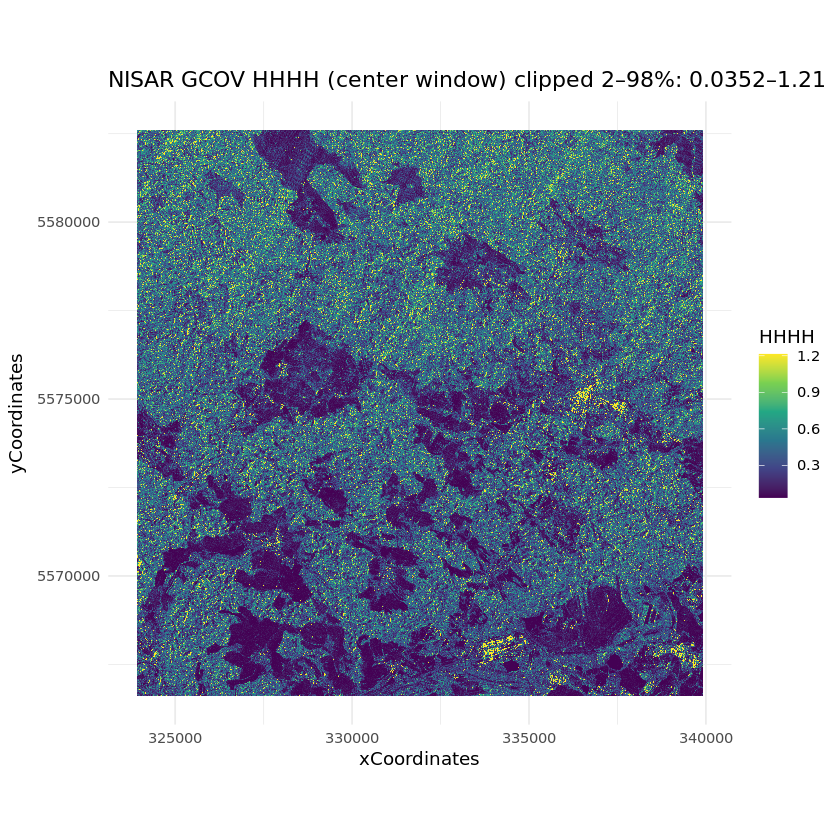

In [11]:
x <- gcov[["xCoordinates"]]$read()
y <- gcov[["yCoordinates"]]$read()
hhhh <- gcov[["HHHH"]]$read()
half <- 800

ny <- dim(hhhh)[1]
nx <- dim(hhhh)[2]

cy <- ny %/% 2
cx <- nx %/% 2

y0 <- max(1, cy - half)
y1 <- min(ny, cy + half)
x0 <- max(1, cx - half)
x1 <- min(nx, cx + half)

hhhh_win <- hhhh[y0:y1, x0:x1]
x_win <- x[x0:x1]
y_win <- y[y0:y1]
vals <- as.numeric(hhhh_win)
vals <- vals[is.finite(vals)]

vmin <- as.numeric(quantile(vals, 0.02, na.rm = TRUE))
vmax <- as.numeric(quantile(vals, 0.98, na.rm = TRUE))
plot_df <- expand.grid(
  xCoordinates = x_win,
  yCoordinates = y_win
)

plot_df$HHHH <- as.vector(hhhh_win)
ggplot(plot_df, aes(x = xCoordinates, y = yCoordinates, fill = HHHH)) +
  geom_raster() +
  coord_equal() +
  scale_fill_viridis_c(
    limits = c(vmin, vmax),
    oob = scales::squish
  ) +
  labs(
    title = sprintf(
      "NISAR GCOV HHHH (center window) clipped 2–98%%: %.3g–%.3g",
      vmin, vmax
    ),
    x = "xCoordinates",
    y = "yCoordinates",
    fill = "HHHH"
  ) +
  theme_minimal()

In [14]:
f$close_all()